#**Sweagy Data Analysis**
**Objective**

Our Goal is to findout following KPI's.
* Total Sales
* Average Rating
* Average Order Value
* Rating Count
* Total Orders

**Charts**

1 Monthly Sales Trend

2  Daily Sales Trend

3 Total Sales by Food Type

4 Total sales by State

5 Quarterly Performance Summary

6 Top 5 cities by Sales

7 weekly Trend Analysis
8 Top 5 Resturent by sales

In [2]:
# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display Settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Ignore Warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Style
plt.style.use('ggplot')

#**Upload Dataset**

In [4]:
# Load Excel file
df = pd.read_excel('sweagy.xlsx')

# Display the first five rows
df.head(5)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


#**Explore the Dataset**


**Check the Shape of the Dataset**

In [5]:
# Check the number of rows and columns
df.shape

(197430, 10)

**Display the Column Names**

In [6]:
# Display all column names
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

**Check Dataset Information**

In [7]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   State            197430 non-null  object        
 1   City             197430 non-null  object        
 2   Order Date       197430 non-null  datetime64[ns]
 3   Restaurant Name  197430 non-null  object        
 4   Location         197430 non-null  object        
 5   Category         197430 non-null  object        
 6   Dish Name        197430 non-null  object        
 7   Price (INR)      197430 non-null  float64       
 8   Rating           197430 non-null  float64       
 9   Rating Count     197430 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 15.1+ MB


#**Statistical Summary**

In [8]:
# Summary statistics
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


#**Statistical Summary for Categorical Features**

In [9]:
# Summary of categorical columns
#Count, Unique values ,Most frequent value (Top),Frequency.
df.describe(include='object')

,State,City,Restaurant Name,Location,Category,Dish Name
count,197430,197430,197430,197430,197430,197430
unique,28,28,993,977,4972,59064
top,Karnataka,Bengaluru,McDonald's,Gomti Nagar,Recommended,Choco Lava Cake
freq,20077,20077,13530,2091,24100,303


#**Display Random Samples**

In [10]:
# Display 5 random rows
df.sample(5, random_state=42)

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
175815,Tripura,Agartala,2025-05-02,Daya Hari Mithai,Kaman Chowmuhani,Soup,Tomato Soup,120.00,3.5,6
79762,Delhi,New Delhi,2025-02-24,Subway,Cleo County,Recommended,Classic Veggie Craver (10cm),169.00,4.5,19
80915,Delhi,New Delhi,2025-07-21,Hira Sweets,Indirapuram,Cookies & Namkeen,Spl. Nam Ajwain Cookies (400 Gms),127.12,5.0,4
161212,Himachal Pradesh,Shimla,2025-08-05,Pizza Hut,Mall Road,Flash Sale Pizzas,Royal Spice Paneer Thin n Crispy Pizza,849.00,4.4,0
78044,Tamil Nadu,Chennai,2025-04-10,Kwality Walls Ice Cream and More,OMR Navalur,Recommended,Oreo & Cream 700ml,299.00,4.6,2


#**Check the Index**

In [11]:
# Display the index
df.index

RangeIndex(start=0, stop=197430, step=1)

#**Check Data Types**

In [12]:
# Display data types
df.dtypes

,0
State,object
City,object
Order Date,datetime64[ns]
Restaurant Name,object
Location,object
Category,object
Dish Name,object
Price (INR),float64
Rating,float64
Rating Count,int64


#**Check for Unique Values**

Identify IDs, categories, and potential data quality issues.

In [13]:
# Number of unique values in each column
df.nunique()

,0
State,28
City,28
Order Date,243
Restaurant Name,993
Location,977
Category,4972
Dish Name,59064
Price (INR),2755
Rating,36
Rating Count,963


#**Count Numerical and Categorical Columns**

In [14]:
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Number of Numerical Columns:", len(numerical_columns))
print(numerical_columns)

Number of Numerical Columns: 3
Index(['Price (INR)', 'Rating', 'Rating Count'], dtype='object')


In [15]:
categorical_columns = df.select_dtypes(include=['object']).columns

print("Number of Categorical Columns:", len(categorical_columns))
print(categorical_columns)

Number of Categorical Columns: 6
Index(['State', 'City', 'Restaurant Name', 'Location', 'Category',
       'Dish Name'],
      dtype='object')


#**Data Cleaning**

**Check for Missing Values**

In [5]:
# Check missing values in each column
df.isnull().sum()

,0
State,0
City,0
Order Date,0
Restaurant Name,0
Location,0
Category,0
Dish Name,0
Price (INR),0
Rating,0
Rating Count,0


**Calculate the percentage of missing values**

In [17]:
# Percentage of missing values
missing_percentage = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': missing_percentage
})

missing_df.sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
State,0,0.0
City,0,0.0
Order Date,0,0.0
Restaurant Name,0,0.0
Location,0,0.0
Category,0,0.0
Dish Name,0,0.0
Price (INR),0,0.0
Rating,0,0.0
Rating Count,0,0.0


#**Remove Duplicate Records**

In [6]:
# Number of duplicate rows
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 27


In [19]:
df = df.drop_duplicates()

print("Duplicates removed successfully.")

Duplicates removed successfully.


#**Convert Data Types**

In [7]:
# Convert Order Date to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [8]:
#Copy the Clean Dataset
df_clean = df.copy()

#Standardize Text Columns

** Remove leading/trailing spaces**


In [9]:
# Remove leading/trailing spaces and convert to lower case
df.columns = df.columns.str.strip().str.lower()

In [10]:
df_clean = df.copy

**Rename Columns**

In [11]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ', '_')

#Check for Negative Values

In [25]:
df.describe()

,order_date,price_(inr),rating,rating_count
count,197403,197403.000000,197403.000000,197403.000000
mean,2025-05-01 19:42:28.028145152,268.501413,4.341579,28.323637
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.222980,0.422585,87.547541


In [27]:
df[df['price_(inr)'] < 0]

,state,city,order_date,restaurant_name,location,category,dish_name,price_(inr),rating,rating_count


**Verify the Cleaned Dataset**

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 197403 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   state            197403 non-null  object        
 1   city             197403 non-null  object        
 2   order_date       197403 non-null  datetime64[ns]
 3   restaurant_name  197403 non-null  object        
 4   location         197403 non-null  object        
 5   category         197403 non-null  object        
 6   dish_name        197403 non-null  object        
 7   price_(inr)      197403 non-null  float64       
 8   rating           197403 non-null  float64       
 9   rating_count     197403 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 16.6+ MB


In [29]:
df.head()

,state,city,order_date,restaurant_name,location,category,dish_name,price_(inr),rating,rating_count
0,Karnataka,Bengaluru,2025-06-29,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,2025-04-03,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,2025-01-15,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,2025-04-17,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,2025-03-13,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [30]:
df.shape

(197403, 10)

#Exploratory Data Analysis (EDA)

**Univariate Analysis**
**Separate Numerical and Categorical Columns**

**Create Column for veg and nonveg**

In [30]:

df['Veg_vs_Nonveg'] = df['dish_name'].apply(
    lambda x: 'Non-Veg' if any(word in str(x).lower()
                               for word in ['chicken','mutton','fish','egg','prawn','meat'])
              else 'Veg'
)
print(df.columns)

Index(['state', 'city', 'order_date', 'restaurant_name', 'location',
       'category', 'dish_name', 'price_(inr)', 'rating', 'rating_count',
       'month', 'day', 'Veg vs Nonveg', 'Veg_vs_Nonveg'],
      dtype='object')


In [12]:
# Separate numerical and categorical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns

print("Numerical Columns:")
print(numerical_cols)

print("\nCategorical Columns:")
print(categorical_cols)

Numerical Columns:
Index(['price_(inr)', 'rating', 'rating_count'], dtype='object')

Categorical Columns:
Index(['state', 'city', 'restaurant_name', 'location', 'category',
       'dish_name'],
      dtype='object')


**Distribution of Numerical Features
Histogram**

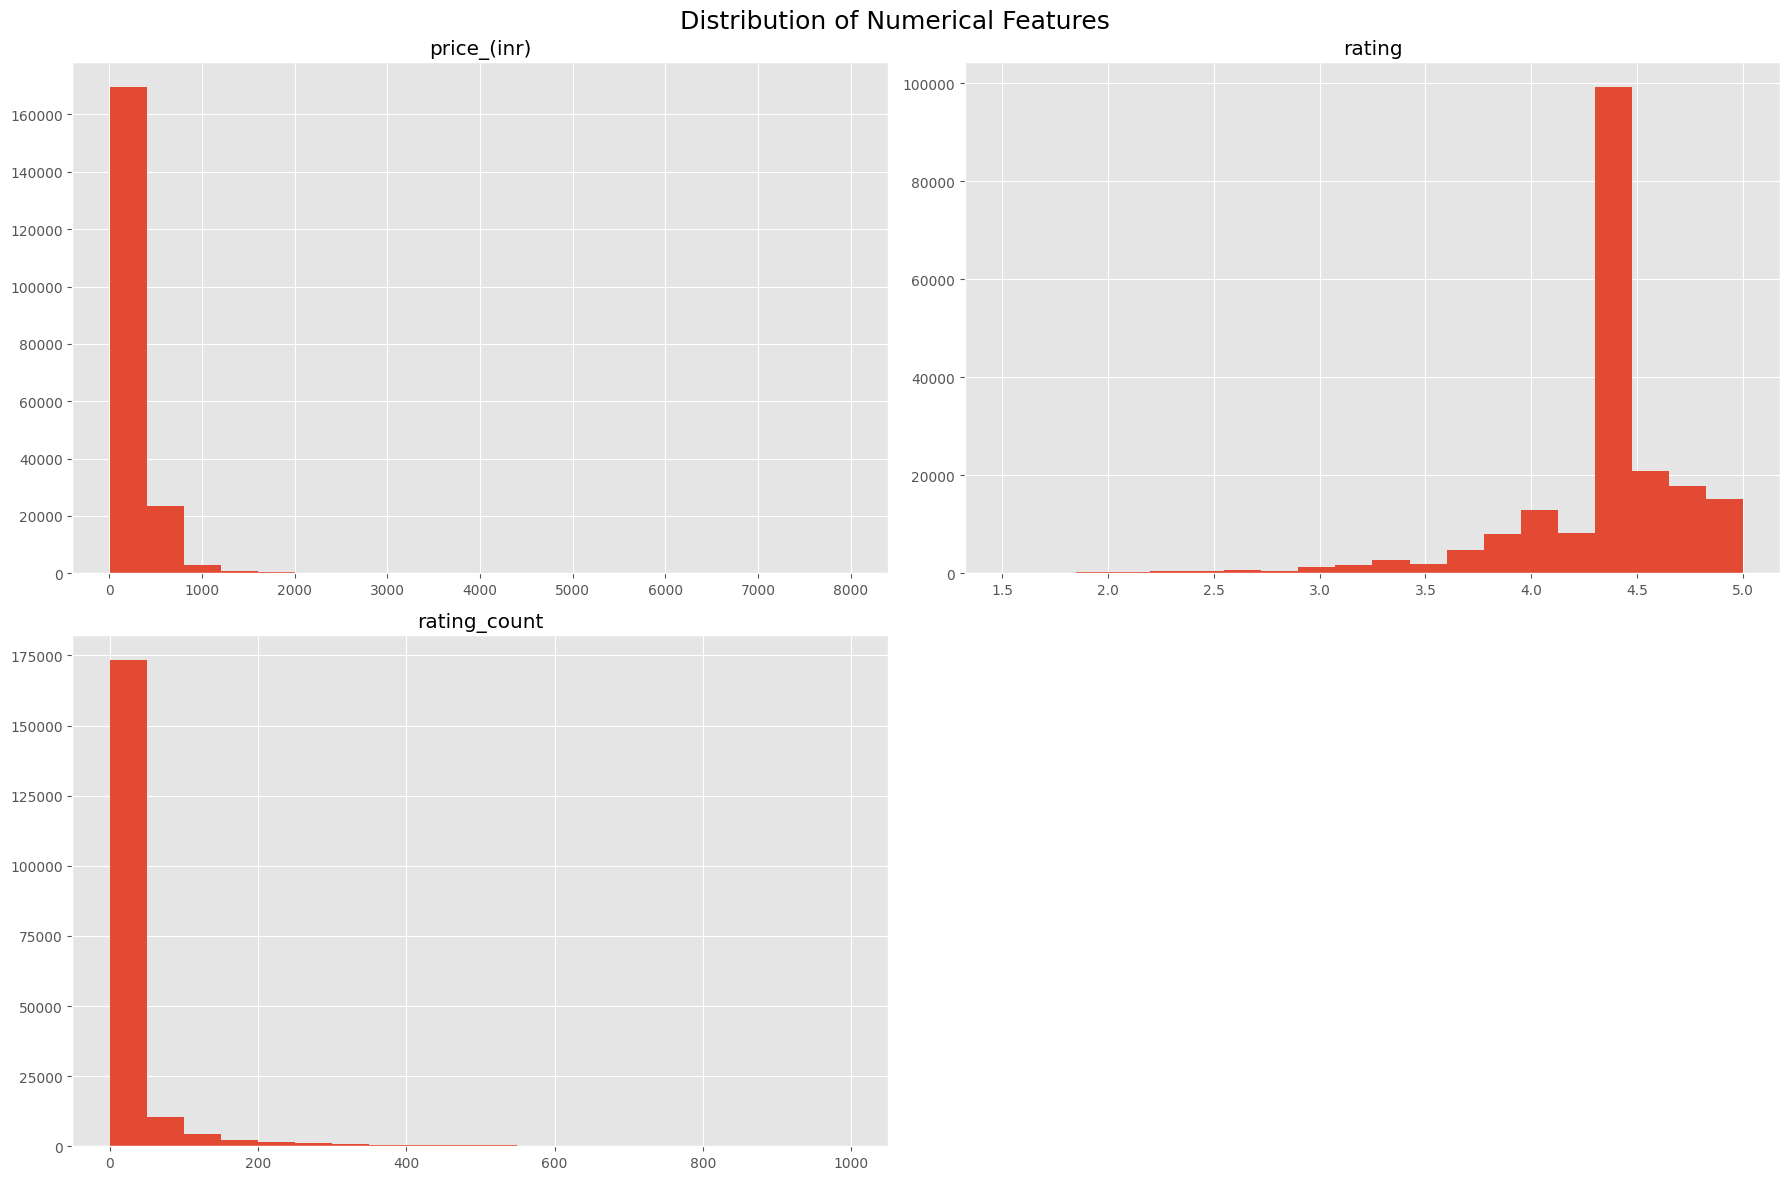

'Business Insight:\n\nIdentify skewed distributions.\nUnderstand the range of values.\nSpot unusual patterns.'

In [32]:
# Histograms for all numerical features
df[numerical_cols].hist(figsize=(18, 12), bins=20)

plt.suptitle("Distribution of Numerical Features", fontsize=18)
plt.tight_layout()
plt.show()

"""Business Insight:

Identify skewed distributions.
Understand the range of values.
Spot unusual patterns."""

**Boxplots (Outlier Detection)**

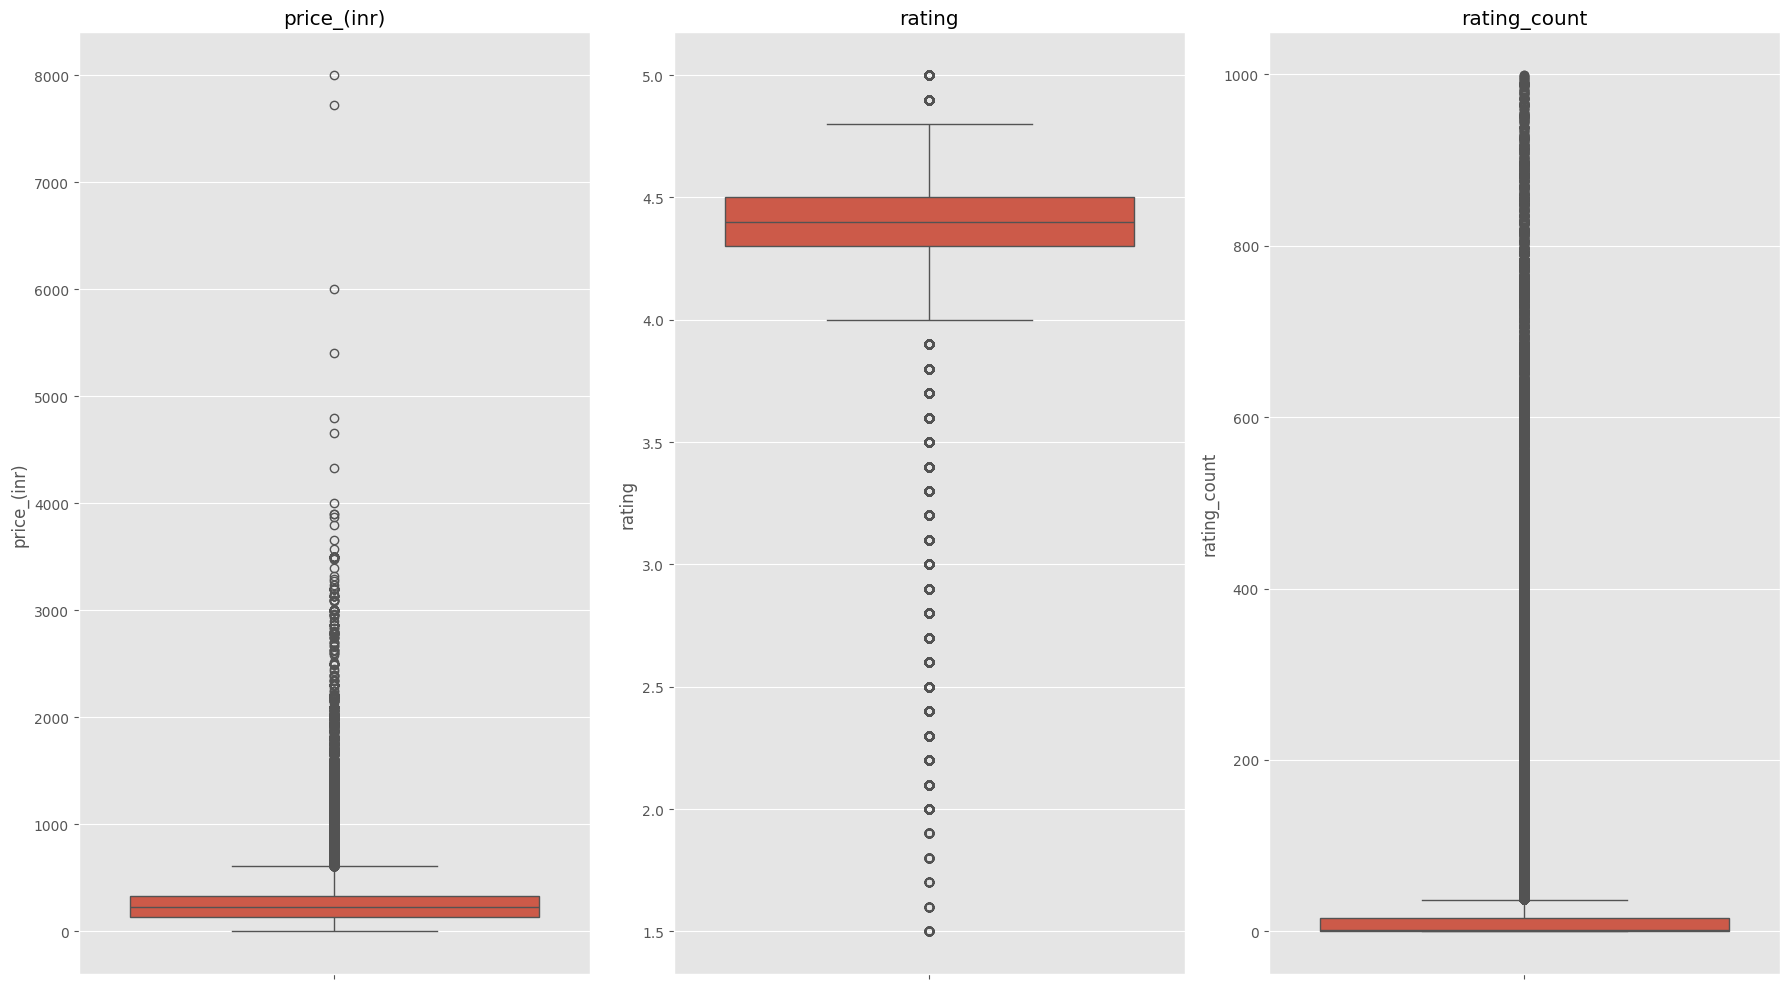

'Business Insight:\n\nDetect unusually high shipping costs.\nIdentify abnormal sales or profits.\nFind inventory anomalies.'

In [33]:
plt.figure(figsize=(18,10))

for i, col in enumerate(numerical_cols):
    plt.subplot((len(numerical_cols)+2)//3, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

'''Business Insight:

Detect unusually high shipping costs.
Identify abnormal sales or profits.
Find inventory anomalies.'''

**Summary Statistics**

In [14]:
df[numerical_cols].describe().T

'''This provides:

Mean
Median
Standard deviation
Minimum
Maximum
Quartiles'''

'This provides:\n\nMean\nMedian\nStandard deviation\nMinimum\nMaximum\nQuartiles'

**Frequency Distribution**

In [35]:
for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].value_counts())


state
state
Karnataka            20072
Maharashtra          10507
Telangana            10309
Rajasthan            10285
Uttar Pradesh        10192
Delhi                10191
Gujarat              10175
Punjab               10060
West Bengal          10044
Tamil Nadu           10042
Madhya Pradesh        7475
Meghalaya             5183
Jharkhand             5101
Uttarakhand           5084
Himachal Pradesh      5054
Assam                 5032
Goa                   5030
Kerala                5029
Chhattisgarh          5025
Odisha                5018
Tripura               5006
Haryana               5005
Manipur               5003
Jammu and Kashmir     5002
Bihar                 5000
Mizoram               3088
Nagaland              2286
Sikkim                2105
Name: count, dtype: int64

city
city
Bengaluru      20072
Mumbai         10507
Hyderabad      10309
Jaipur         10285
Lucknow        10192
New Delhi      10191
Ahmedabad      10175
Chandigarh     10060
Kolkata        10044
Chenn

**Countplots**


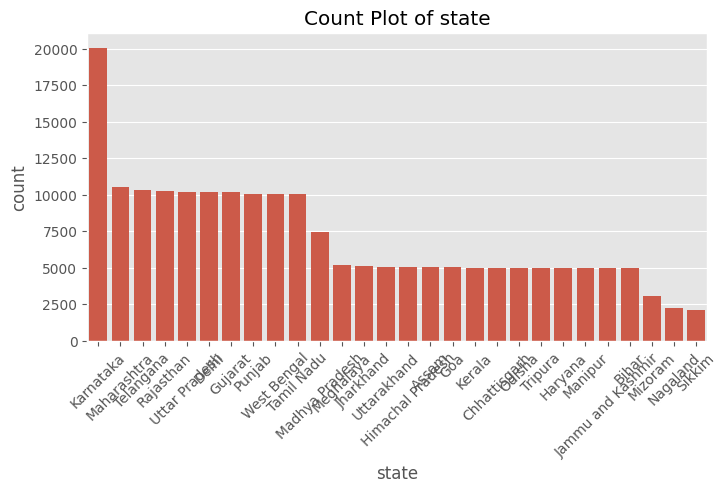

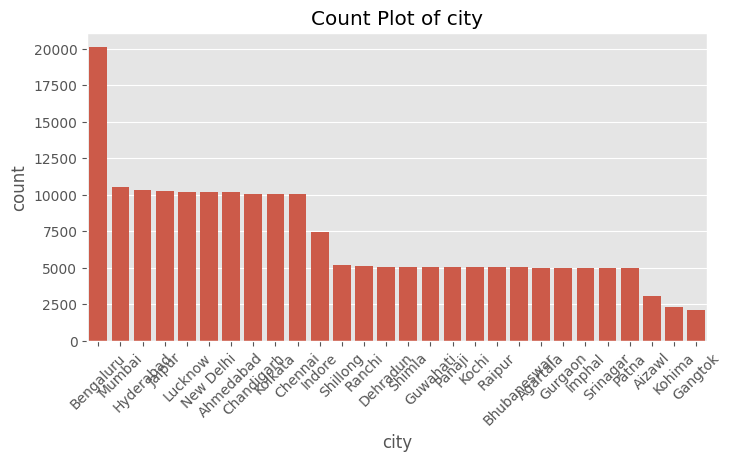

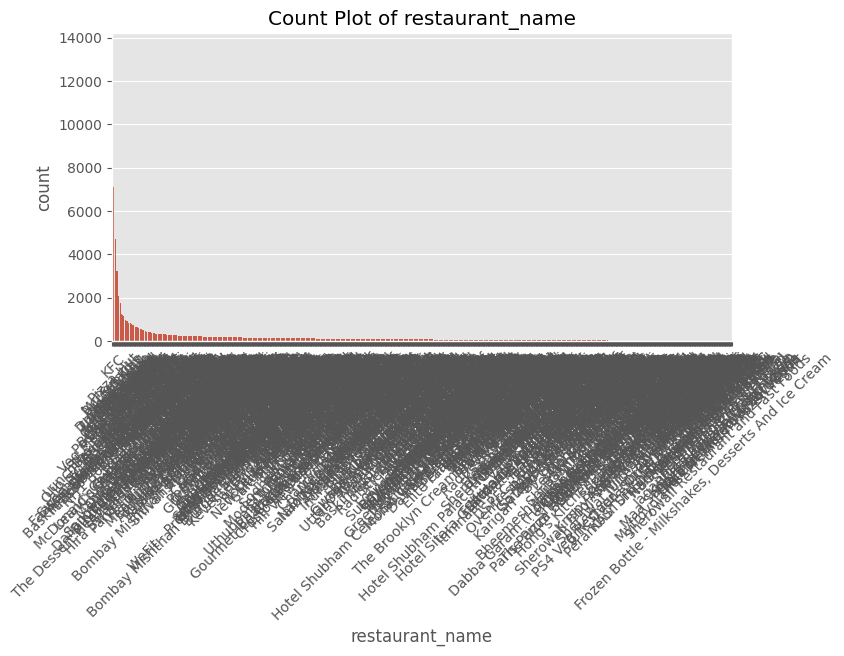

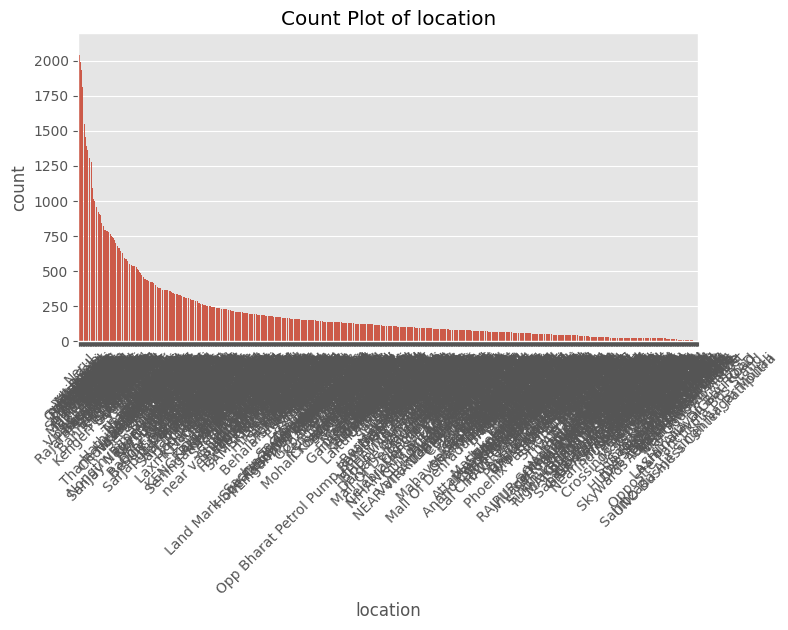

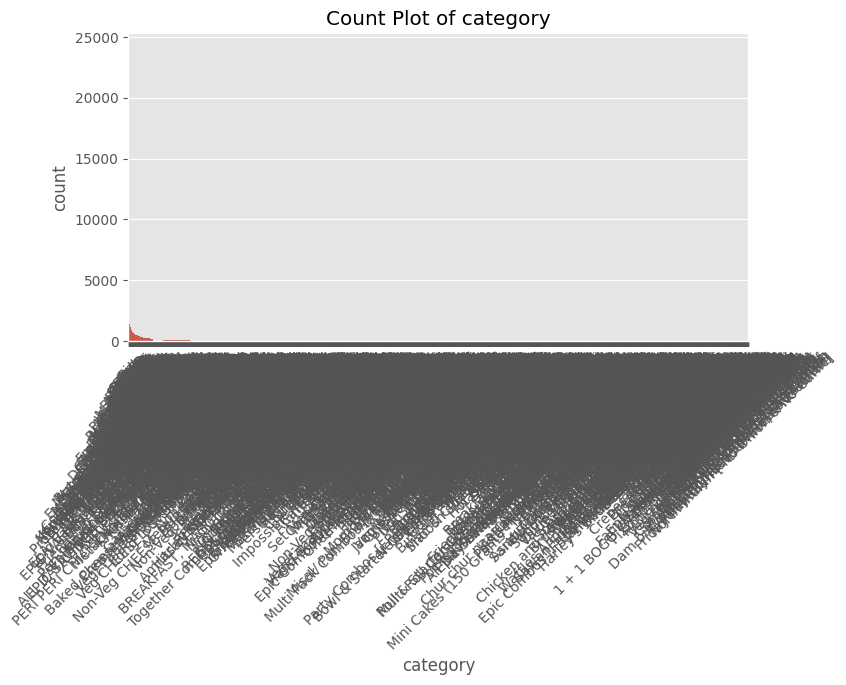

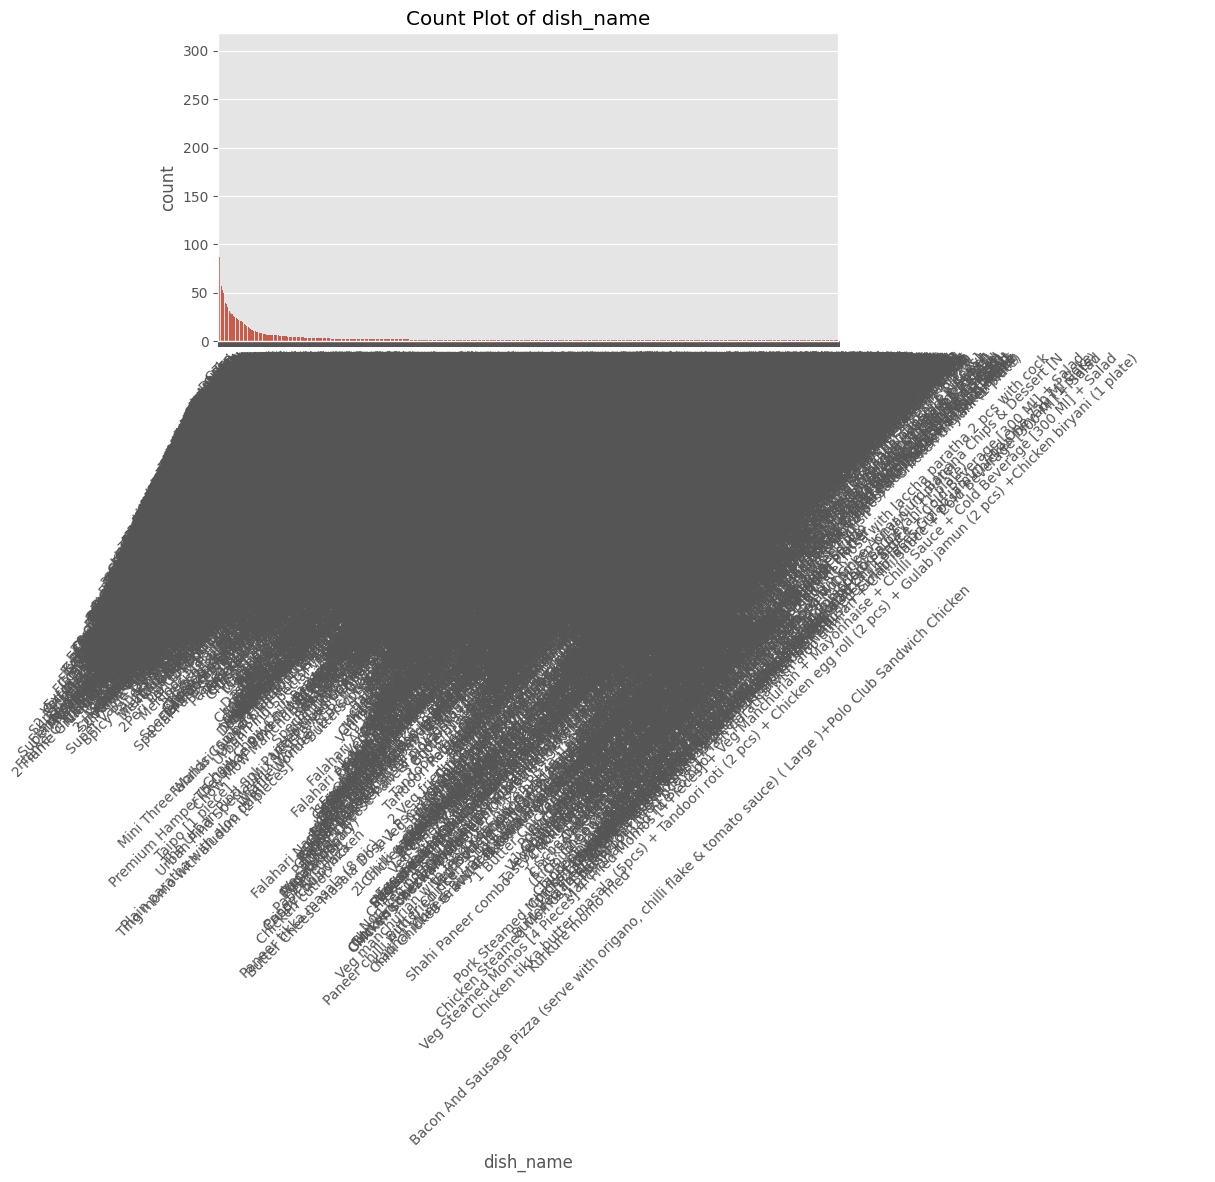

In [36]:
for col in categorical_cols:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=col,
        order=df[col].value_counts().index
    )

    plt.xticks(rotation=45)
    plt.title(f"Count Plot of {col}")

    plt.show()

    '''Business Insight:

Most common shipping mode
Most active supplier
Most frequent region
Most popular product category'''

**Pie Charts (Low-Cardinality Categories)**

#**Part C: Business KPIs (Initial)**

**Total  Orders**

In [38]:
print("Total Orders:", len(df))

Total Orders: 197403


**Total Sales**

In [39]:
if 'price_(inr)' in df.columns:
    print("Total Revenue:", df['price_(inr)'].sum())


Total Revenue: 53002984.47


**Average Order Value**

In [44]:
if 'price_(inr)' in df.columns:
    print("Average Order Value:", df['price_(inr)'].mean())

Average Order Value: 268.5014132004073


**Total Available Dishes**

In [40]:
if 'dish_name' in df.columns:
    print("Unique Products:", df['dish_name'].nunique())

Unique Products: 59064


**Total Restaurants**

In [41]:
if 'restaurant_name' in df.columns:
    print("Total Restaurants:", df['restaurant_name'].nunique())

Total Restaurants: 993


**Total Rating**

In [45]:
if 'rating' in df.columns:
    print("Total Rating:", df['rating'].count())

Total Rating: 197403


**Number of Customers**

In [ ]:
#if 'Customer ID' in df.columns:
    #print("Total Customers:", df['Customer ID'].nunique())

**Average Rating**

In [46]:
if 'rating' in df.columns:
    print("Average Rating:", df['rating'].mean())

Average Rating: 4.34157890204303


#**Business Questions Answered**
After this phase, we'll be able to answer questions like:
*   Which food category appears most frequently?
*   Which restaurant have ordered the most?
*   Are there outliers in sales, profit, or shipping costs?
*   Is the data normally distributed or skewed?
*   Which order status is most common?
*   Are there any unusual business patterns that require attention?

#**Part A: Bivariate Analysis**

**Sales vs Profit**

**Line Chart**

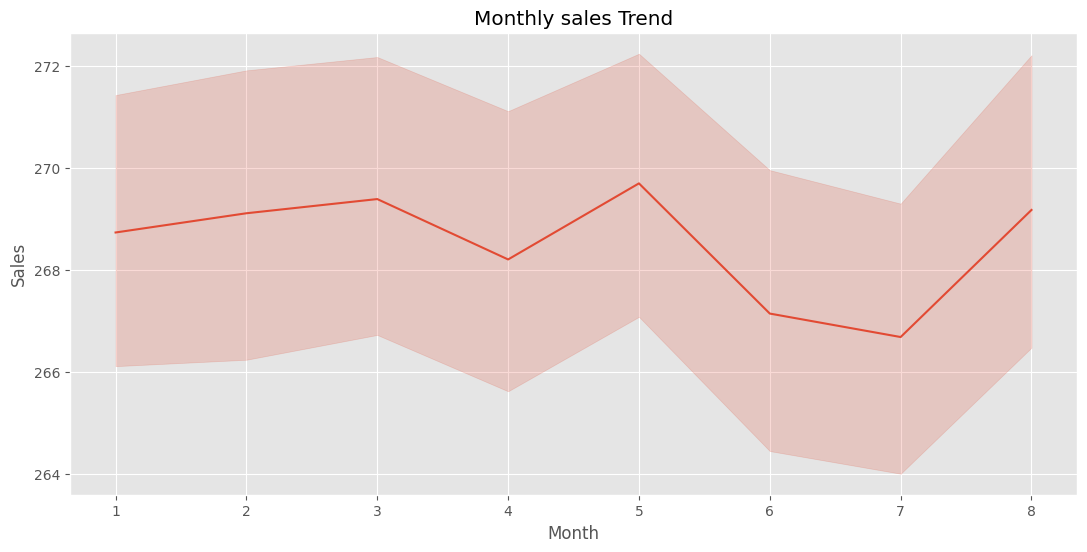

In [20]:
plt.figure(figsize=(13,6))

df['month'] = df['order_date'].dt.month

sns.lineplot(
    data=df,
    x='month',
    y='price_(inr)'
)

plt.title("Monthly sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

**Daily Sales Trend**

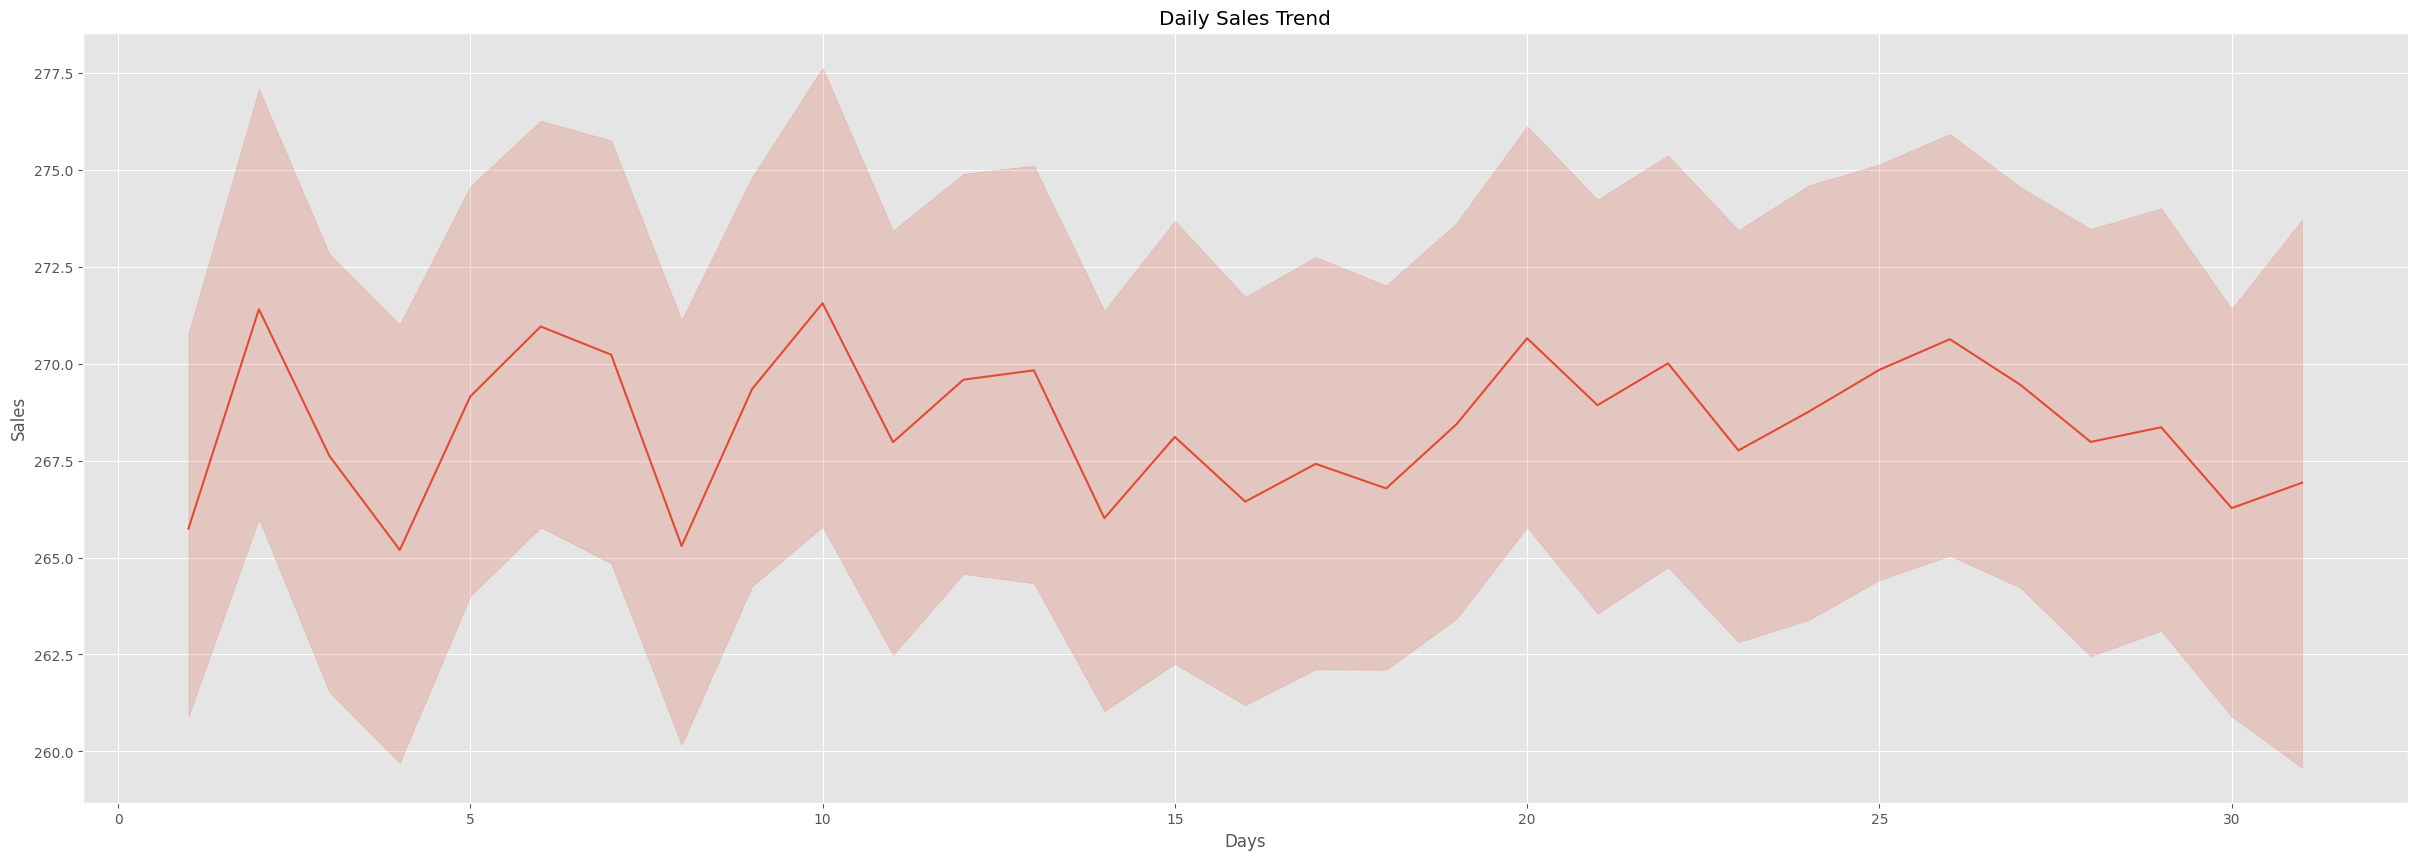

In [23]:
plt.figure(figsize=(30,10))
df['day'] = df['order_date'].dt.day

sns.lineplot(
    data=df,
    x='day',
    y='price_(inr)'
)

plt.title("Daily Sales Trend")
plt.xlabel("Days")
plt.ylabel("Sales")
plt.show()


**Order Quantity vs Profit**

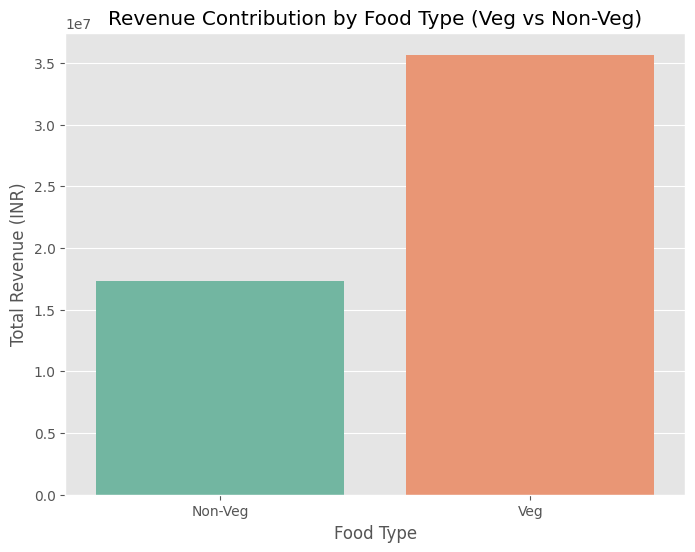

In [48]:

# Aggregate revenue by food type (Veg vs Non-Veg)

food_revenue = df.groupby('Veg_vs_Nonveg')['price_(inr)'].sum().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(
    data=food_revenue,
    x='Veg_vs_Nonveg',
    y='price_(inr)',
    palette='Set2'
)

plt.title("Revenue Contribution by Food Type (Veg vs Non-Veg)")
plt.xlabel("Food Type")
plt.ylabel("Total Revenue (INR)")
plt.show()


**Revenue by State**

In [49]:
import plotly.express as px
# Aggregate revenue by state
state_revenue = df.groupby('state')['price_(inr)'].sum().reset_index()

# Create choropleth map
fig = px.choropleth(
    state_revenue,
    locations='state',              # column with state names
    # locationmode='country names',   # assumes states are valid names
    color='price_(inr)',            # revenue values
    hover_name='state',
    color_continuous_scale='Viridis',
    title="State-wise Revenue Contribution"
)

fig.show()

'''Business Insight
Which supplier delivers the fastest?
Which supplier has inconsistent delivery performance?'''

'Business Insight\nWhich supplier delivers the fastest?\nWhich supplier has inconsistent delivery performance?'

  Quarter  Total_Sales  Avg_Rating  Total_Orders
0  2025Q1  19667821.77    4.342643         73096
1  2025Q2  19902256.59    4.340011         74163
2  2025Q3  13442427.41    4.342359         50171


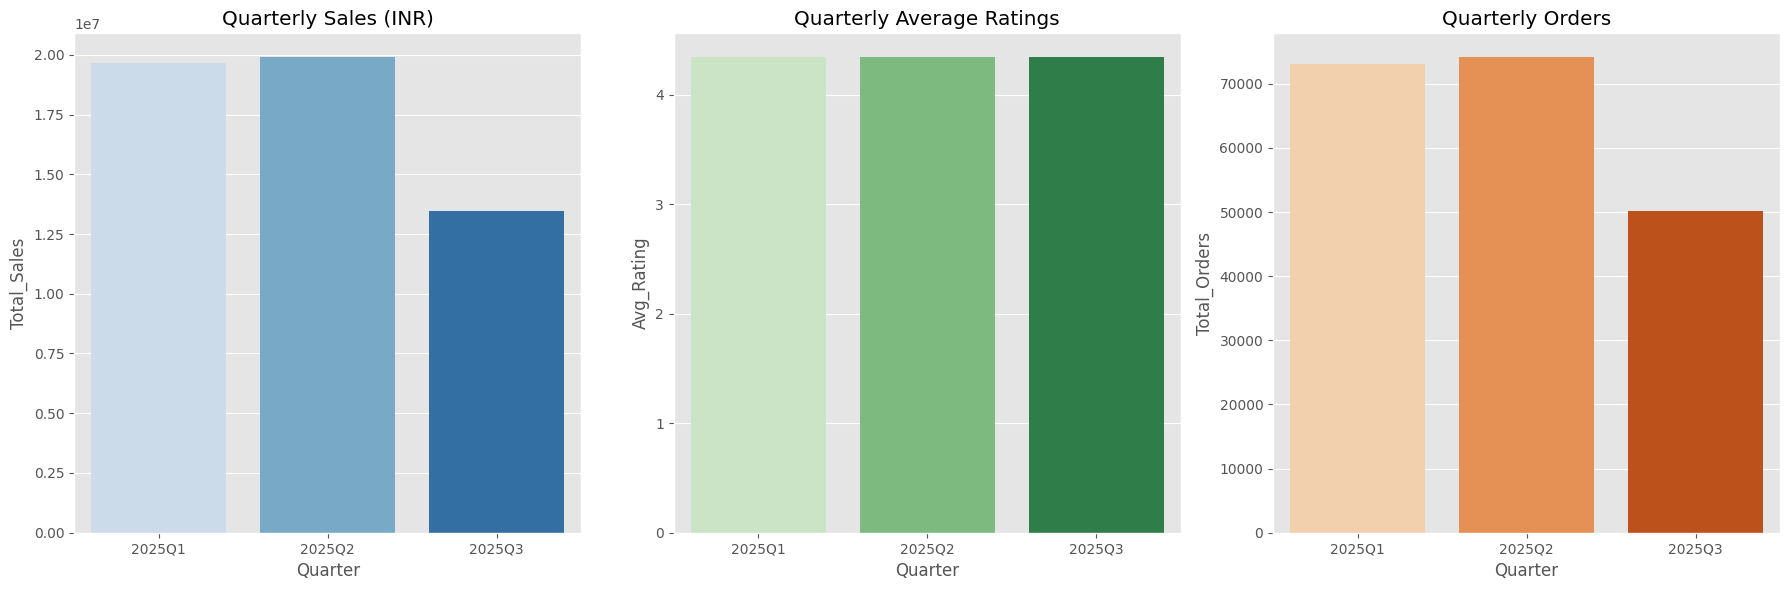

In [52]:

# Ensure 'order_date' column is in datetime format

df['order_date'] = pd.to_datetime(df['order_date'])

# Create a Quarter column
df['Quarter'] = df['order_date'].dt.to_period('Q')

# Aggregate metrics by Quarter
quarterly_summary = df.groupby('Quarter').agg({
    'price_(inr)': 'sum',       # Total Sales
    'rating': 'mean',          # Average Ratings
    'order_date': 'count'         # Total Orders
}).reset_index()

# Rename columns for clarity
quarterly_summary.rename(columns={
    'price_(inr)': 'Total_Sales',
    'rating': 'Avg_Rating',
    'order_date': 'Total_Orders' # Changed 'rating_count' to 'order_date' based on the agg function
}, inplace=True)

print(quarterly_summary)

# --- Visualization ---
fig, axes = plt.subplots(1, 3, figsize=(18,6))

# Sales by Quarter
sns.barplot(data=quarterly_summary, x='Quarter', y='Total_Sales', ax=axes[0], palette='Blues')
axes[0].set_title("Quarterly Sales (INR)")

# Ratings by Quarter
sns.barplot(data=quarterly_summary, x='Quarter', y='Avg_Rating', ax=axes[1], palette='Greens')
axes[1].set_title("Quarterly Average Ratings")

# Orders by Quarter
sns.barplot(data=quarterly_summary, x='Quarter', y='Total_Orders', ax=axes[2], palette='Oranges')
axes[2].set_title("Quarterly Orders")

plt.tight_layout()
plt.show()

**Region vs Revenue**

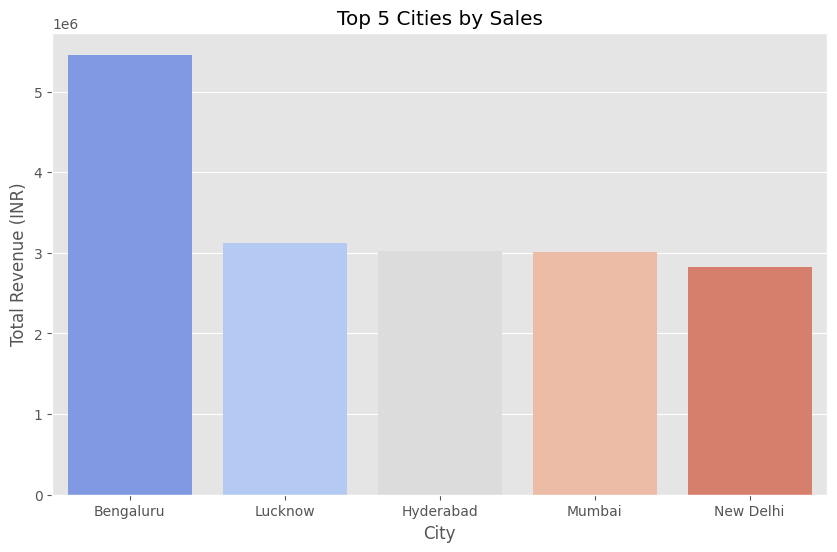

In [55]:
# Aggregate revenue by city
city_revenue = df.groupby('city')['price_(inr)'].sum().reset_index()

# Sort and select top 5 cities
top5_cities = city_revenue.sort_values(by='price_(inr)', ascending=False).head(5)

# --- Visualization ---
plt.figure(figsize=(10,6))
sns.barplot(
    data=top5_cities,
    x='city',
    y='price_(inr)',
    palette='coolwarm'
)

plt.title("Top 5 Cities by Sales")
plt.xlabel("City")
plt.ylabel("Total Revenue (INR)")
plt.show()

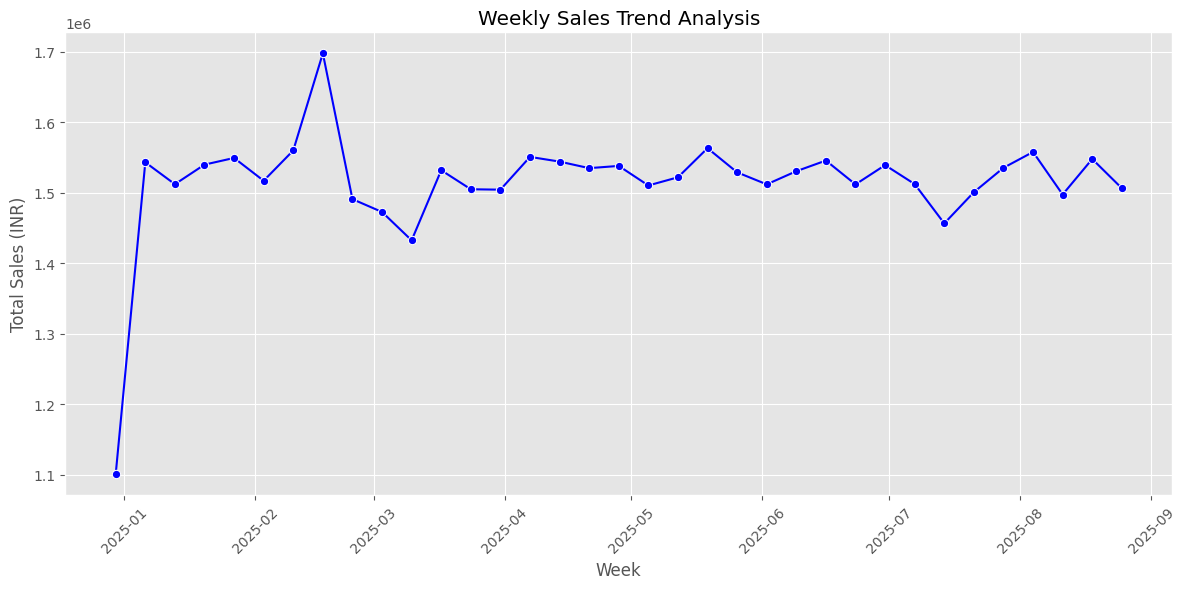

In [56]:
# Ensure 'date' column is in datetime format
df['date'] = pd.to_datetime(df['order_date'])

# Create a Week column (ISO week or start-of-week date)
df['Week'] = df['order_date'].dt.to_period('W').apply(lambda r: r.start_time)

# Aggregate weekly sales
weekly_sales = df.groupby('Week')['price_(inr)'].sum().reset_index()

# --- Visualization ---
plt.figure(figsize=(12,6))
sns.lineplot(
    data=weekly_sales,
    x='Week',
    y='price_(inr)',
    marker='o',
    color='blue'
)

plt.title("Weekly Sales Trend Analysis")
plt.xlabel("Week")
plt.ylabel("Total Sales (INR)")
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#**Part B: Multivariate Analysis**

**Correlation Matrix**

1.   First, select only numerical columns.
2.   Now calculate correlations.



In [ ]:
numerical_df = df.select_dtypes(include=['int64','float64'])

In [ ]:
corr_matrix = numerical_df.corr()

corr_matrix

#**Correlation Heatmap**

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Matrix")

plt.show()

'''Business Insight

Look for:

Strong Positive Correlation (close to +1)
Strong Negative Correlation (close to -1)
Weak Correlation (around 0)

For example:

Sales ↔ Profit
Quantity ↔ Sales
Shipping Cost ↔ Profit'''

#**Pairplot (Selected Features)**
Avoid using all columns because it becomes cluttered.

In [ ]:
selected_features = [
    'Sales',
    'Profit',
    'Shipping Cost',
    'Order Quantity'
]

sns.pairplot(df[selected_features])

plt.show()

'''Business Insight

This helps visualize:

Relationships between every pair of selected variables.
Distributions of each variable.
Potential clusters or outliers.'''

#**Pairplot with Category (Optional)**
If your dataset contains a category column (e.g., Product Category):

In [ ]:
selected_features = [
    'Sales',
    'Profit',
    'Shipping Cost',
    'Order Quantity',
    'Category'
]

sns.pairplot(
    df[selected_features],
    hue='Category'
)

plt.show()

'''This lets you compare relationships across different product categories'''

#**Grouped Business Analysis**

**Sales & Profit by Region**

In [ ]:
region_summary = (
    df.groupby('Region')[['Sales', 'Profit']]
      .sum()
      .sort_values(by='Sales', ascending=False)
)

region_summary

**Supplier Performance**

In [ ]:
supplier_summary = (
    df.groupby('Supplier Name')
      .agg({
          'Sales':'sum',
          'Profit':'sum',
          'Delivery Time':'mean'
      })
      .sort_values(by='Profit', ascending=False)
)

supplier_summary

Business Questions Answered

By completing this step, you'll be able to answer questions such as:

1 Which regions generate the most revenue and profit?
2 Which suppliers are the most reliable and profitable?
3 Does increasing order quantity improve profitability?
4 Are shipping costs aligned with sales value?
5 Which variables are most strongly correlated?
6 Are there hidden patterns or clusters among sales, profit, quantity, and shipping costs?

#**Step 7: Business KPIs & Executive Dashboard**

**Executive Summary KPIs**

These are the KPI cards that will appear at the top of our dashboard.

**1)  Total Revenue**




In [ ]:
# Total Revenue
total_revenue = df['Sales'].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

**Total Profit**

In [ ]:
# Total Profit
total_profit = df['Profit'].sum()

print(f"Total Profit: ${total_profit:,.2f}")

**Total Orders**

In [ ]:
# Total Orders
total_orders = len(df)

print("Total Orders:", total_orders)

**Average Order Value (AOV)**

In [ ]:
# Average Order Value
average_order_value = df['Sales'].mean()

print(f"Average Order Value: ${average_order_value:,.2f}")

**Total Customers**

In [ ]:
# Total Customers
total_customers = df['Customer ID'].nunique()

print("Total Customers:", total_customers)

**Total Products**

In [ ]:
# Total Products
total_products = df['Product Name'].nunique()

print("Total Products:", total_products)

**Profit Margin**

In [ ]:
# Profit Margin
profit_margin = (total_profit / total_revenue) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

#**Inventory KPIs**

**Average Inventory Level**

In [ ]:
average_inventory = df['Inventory Level'].mean()

print(f"Average Inventory Level: {average_inventory:.2f}")

**Stock Availability**

In [ ]:
stock_available = (df['Inventory Level'] > 0).sum()

print("Products In Stock:", stock_available)

**Low Stock Products**

In [ ]:
low_stock = df[df['Inventory Level'] < 20]

print(low_stock[['Product Name', 'Inventory Level']])

#**Logistics KPIs**

**Average Delivery Time**

In [ ]:
average_delivery = df['Delivery Time'].mean()

print(f"Average Delivery Time: {average_delivery:.2f} Days")

**Average Shipping Cost**

In [ ]:
average_shipping = df['Shipping Cost'].mean()

print(f"Average Shipping Cost: ${average_shipping:.2f}")

**Total Shipping Cost**

In [ ]:
total_shipping = df['Shipping Cost'].sum()

print(f"Total Shipping Cost: ${total_shipping:,.2f}")

#**Supplier KPIs**
7.14 **Supplier Performance**

In [ ]:
supplier_performance = (
    df.groupby('Supplier Name')
      .agg({
          'Sales':'sum',
          'Profit':'sum',
          'Delivery Time':'mean'
      })
      .sort_values(by='Profit', ascending=False)
)

supplier_performance

#**Regional KPIs**

7.15 **Revenue by Region**

In [ ]:
region_sales = (
    df.groupby('Region')['Sales']
      .sum()
      .sort_values(ascending=False)
)

region_sales

**Profit by Region**

In [ ]:
region_profit = (
    df.groupby('Region')['Profit']
      .sum()
      .sort_values(ascending=False)
)

region_profit

#**Product KPIs**

**7.17 Best Selling Products**

In [ ]:
top_products = (
    df.groupby('Product Name')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

7.18 **Most Profitable Products**

In [ ]:
top_profit_products = (
    df.groupby('Product Name')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_profit_products

#**Customer KPIs**

**7.19 Top Customers**

In [ ]:
top_customers = (
    df.groupby('Customer ID')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers

**7.20 Customer Profitability**

In [ ]:
customer_profit = (
    df.groupby('Customer ID')['Profit']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

customer_profit

#**Time-Based KPIs**
Assuming Order Date has been converted to datetime

**Monthly Revenue**

In [ ]:
monthly_sales = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Sales']
      .sum()
)

monthly_sales

**Monthly Profit**

In [ ]:
monthly_profit = (
    df.groupby(df['Order Date'].dt.to_period('M'))['Profit']
      .sum()
)

monthly_profit

#**Dashboard Visualizations**

**Revenue by Region**

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Revenue by Region")
plt.xticks(rotation=45)
plt.ylabel("Revenue")
plt.show()

**Top 10 Products**

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_products.values,
    y=top_products.index
)

plt.title("Top 10 Best Selling Products")
plt.xlabel("Sales")
plt.ylabel("Product")
plt.show()

**Monthly Sales Trend**

In [ ]:
monthly_sales.plot(
    figsize=(12,5),
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.grid(True)

plt.show()

#**Part 1: Interactive Dashboard (Plotly)**

Instead of static charts, we'll build an interactive dashboard

**Dashboard Layout**

In [ ]:
-------------------------------------------------------
                 SUPPLY CHAIN DASHBOARD
-------------------------------------------------------

 KPI Cards

 Revenue      Profit      Orders      Customers

-------------------------------------------------------

Monthly Sales Trend

-------------------------------------------------------

Revenue by Region

-------------------------------------------------------

Top Products

-------------------------------------------------------

Supplier Performance

-------------------------------------------------------

Shipping Cost Analysis

-------------------------------------------------------

Profit by Category

-------------------------------------------------------

Delivery Performance

-------------------------------------------------------

Dashboard Components,
KPI Cards,
Total Revenue,
Total Profit,
Profit Margin,
Total Orders,
Average Delivery Time,
Total Customers,
Revenue Analysis,
Monthly Revenue Trend,
Quarterly Revenue,
Revenue by Region,
Product Analysis,
Top 10 Products,
Product Category Performance,
Product Profitability,
Logistics Analysis.
Shipping Cost,
Delivery Time,
Delayed Orders,
Shipping Mode,
Supplier Analysis,
Average Delivery Time,
Revenue by Supplier,
Supplier Reliability,
Customer Analysis,
Customer Revenue,
Customer Profitability,
Filters,

Interactive filters:

Region,
Product Category,
Supplier,
Customer,
Shipping Mode,
Year,
Month,